In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import svm
#Elastic Net Classifier. Uses Logistic Regression with elasticnet penalty as the base estimator.
from sklearn.linear_model import LogisticRegression
import shap
!pip install optuna
import optuna
from time import time

In [ ]:
x_train = pd.read_csv('X_train_for_cs.csv')
x_test = pd.read_csv('X_test_for_cs.csv')
y_train = pd.read_csv('y_train_for_cs.csv')
y_test = pd.read_csv('y_test_for_cs.csv')
#data = pd.read_csv('data_for_cs.csv')
x_train.drop(columns='Unnamed: 0', inplace=True)
x_test.drop(columns='Unnamed: 0', inplace=True)
y_train.drop(columns='Unnamed: 0', inplace=True)
y_test.drop(columns='Unnamed: 0', inplace=True)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [ ]:
#RandomForest no extra methods
time_rf_basic = time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred = rf.predict(x_test)
print(classification_report(y_test, y_pred))
print('Model training time',time()-time_rf_basic)
delta_time_rf1 = time()-time_rf_basic
#accuracy — the percentage of correct algorithm responses
#Precision can be interpreted as the proportion of objects that are called positive by the classifier and are actually positive at the same time.
#recall shows what proportion of objects of a positive class out of all objects of a positive class the algorithm has found.


              precision    recall  f1-score   support

         bad       0.69      0.42      0.53        59
        good       0.79      0.92      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.67      0.69       200
weighted avg       0.76      0.78      0.76       200

Model training time 0.27129244804382324


Text(0.5, 1.0, 'Global Feature Importance')

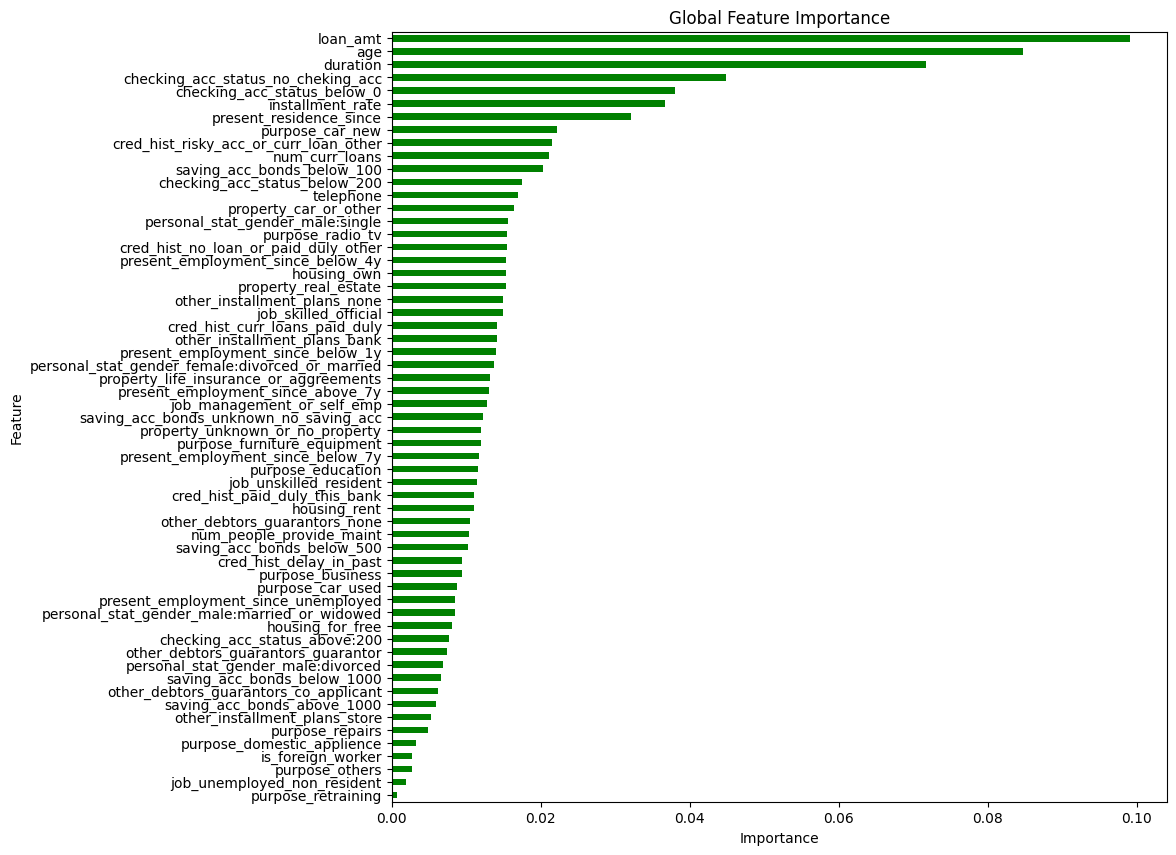

In [ ]:
global_importances = pd.Series(rf.feature_importances_, index=x_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='green', figsize = (10, 10))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Global Feature Importance")

In [ ]:
#optuna for optimization
#https://habr.com/ru/companies/otus/articles/801463/
#optuna documentation: https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/002_configurations.html
study = optuna.create_study(study_name="for_rf", direction="maximize")


def objective(trial):
  n_estimators = trial.suggest_int('n_estimators', 1, 120)

  rf_optuna = RandomForestClassifier(n_estimators=n_estimators, random_state = 42)
  rf_optuna.fit(x_train, y_train)
  y_pred_best = rf_optuna.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred_best)
  return(accuracy)

time_rf_mod = time()


study.optimize(objective, n_trials=100)
print(study.best_params)
print('Model training time',time() -  time_rf_mod)
delta_time_rf2 = time()-time_rf_mod

[I 2026-01-26 21:00:26,837] A new study created in memory with name: for_rf
[I 2026-01-26 21:00:27,261] Trial 0 finished with value: 0.78 and parameters: {'n_estimators': 101}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:27,861] Trial 1 finished with value: 0.77 and parameters: {'n_estimators': 98}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:27,973] Trial 2 finished with value: 0.76 and parameters: {'n_estimators': 33}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:28,126] Trial 3 finished with value: 0.775 and parameters: {'n_estimators': 37}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:28,449] Trial 4 finished with value: 0.775 and parameters: {'n_estimators': 94}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:28,812] Trial 5 finished with value: 0.78 and parameters: {'n_estimators': 103}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:00:29,406] Trial 6 finished with value: 0.78 and parameters: {'n_estimators': 112}. Best is trial 0

{'n_estimators': 119}
Model training time 39.809972047805786


In [ ]:
n_estimators_best = study.best_params['n_estimators']
rf_best = RandomForestClassifier(n_estimators=n_estimators_best, random_state=42)
rf_best.fit(x_train, y_train)
y_pred_best = rf_best.predict(x_test)
print("Model training time, n_estimators = 100")
print(classification_report(y_test, y_pred))
print("A model improved using the OPTUNA framework")
print(classification_report(y_test, y_pred_best))

Model training time, n_estimators = 100
              precision    recall  f1-score   support

         bad       0.69      0.42      0.53        59
        good       0.79      0.92      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.67      0.69       200
weighted avg       0.76      0.78      0.76       200

A model improved using the OPTUNA framework
              precision    recall  f1-score   support

         bad       0.75      0.46      0.57        59
        good       0.80      0.94      0.87       141

    accuracy                           0.80       200
   macro avg       0.78      0.70      0.72       200
weighted avg       0.79      0.80      0.78       200



Text(0.5, 1.0, 'Global Feature Importance')

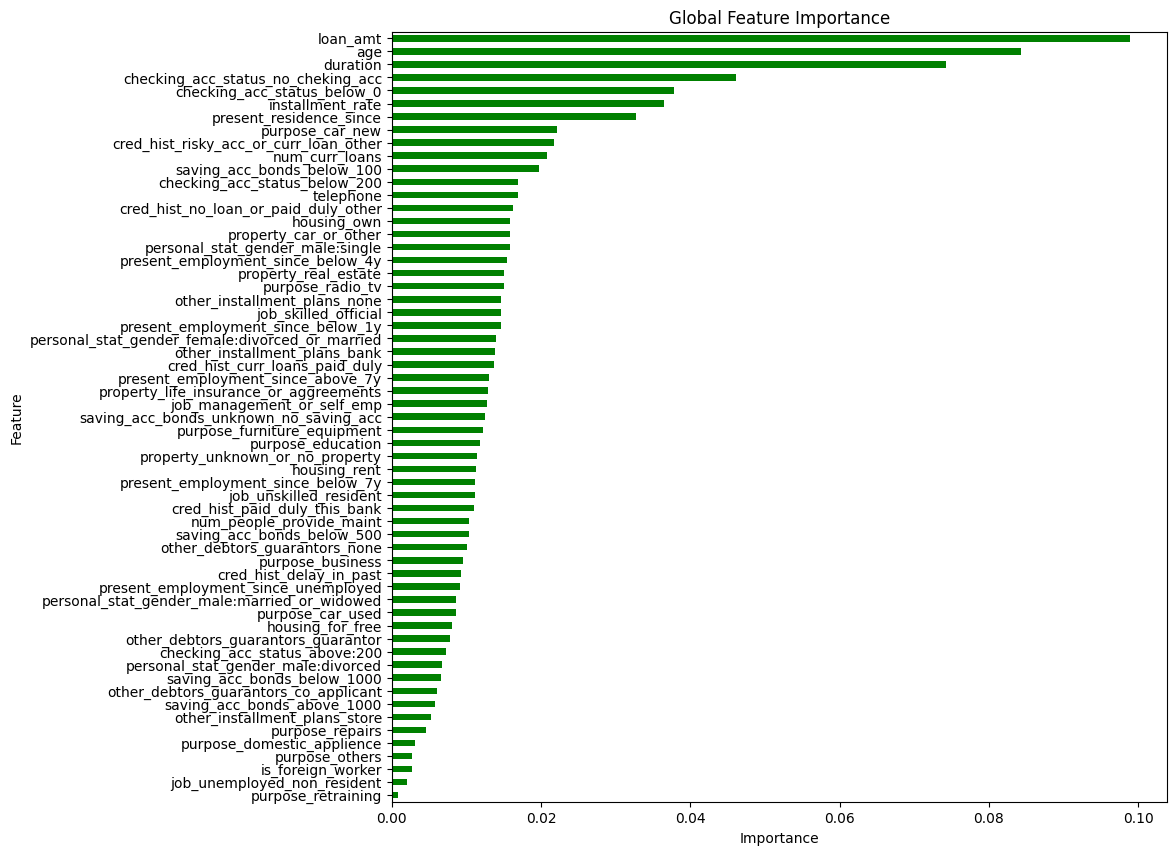

In [ ]:
global_importances = pd.Series(rf_best.feature_importances_, index=x_train.columns)
global_importances.sort_values(ascending=True, inplace=True)
global_importances.plot.barh(color='green', figsize = (10, 10))
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Global Feature Importance")

In [ ]:
#SVC(Support Vector Classifier)
#SVC doc: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC
#
time_SVC_basic = time()
clf_SVC = svm.SVC()
clf_SVC.fit(x_train, y_train)

y_pred_SVC = clf_SVC.predict(x_test)
print(classification_report(y_test, y_pred_SVC))
print('model training time:', time() - time_SVC_basic)
delta_time_SVC1 = time() - time_SVC_basic

              precision    recall  f1-score   support

         bad       0.75      0.05      0.10        59
        good       0.71      0.99      0.83       141

    accuracy                           0.71       200
   macro avg       0.73      0.52      0.46       200
weighted avg       0.72      0.71      0.61       200

model training time: 0.07344985008239746


In [ ]:
#let's try to improve the indicators by selecting parameters
#We will iterate over "C" and gamma for rbf core

def objective_SVC(trial):
  c = trial.suggest_float('C', 1e-5, 1e5)
  gamma = trial.suggest_float('gamma', 1e-5, 1e-1)
  clf_SVC_best = svm.SVC(C = c, gamma = gamma)
  clf_SVC_best.fit(x_train, y_train)

  y_pred_SVC_best = clf_SVC_best.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred_SVC_best)
  return accuracy

time_SVC_mod = time()
study_for_SVC = optuna.create_study(study_name="for_SVC", direction="maximize")
study_for_SVC.optimize(objective_SVC, n_trials=100)


[I 2026-01-26 21:01:07,737] A new study created in memory with name: for_SVC
[I 2026-01-26 21:01:07,808] Trial 0 finished with value: 0.705 and parameters: {'C': 66998.16165091647, 'gamma': 0.07962084177458216}. Best is trial 0 with value: 0.705.
[I 2026-01-26 21:01:07,890] Trial 1 finished with value: 0.705 and parameters: {'C': 46553.863037052004, 'gamma': 0.08665998655019003}. Best is trial 0 with value: 0.705.
[I 2026-01-26 21:01:07,961] Trial 2 finished with value: 0.705 and parameters: {'C': 12875.13352568599, 'gamma': 0.09530206238641813}. Best is trial 0 with value: 0.705.
[I 2026-01-26 21:01:08,032] Trial 3 finished with value: 0.71 and parameters: {'C': 74018.05823775186, 'gamma': 0.038901705971006305}. Best is trial 3 with value: 0.71.
[I 2026-01-26 21:01:08,100] Trial 4 finished with value: 0.705 and parameters: {'C': 41288.337699961994, 'gamma': 0.054920343765561964}. Best is trial 3 with value: 0.71.
[I 2026-01-26 21:01:08,170] Trial 5 finished with value: 0.705 and param

In [ ]:
print('Model training time', time() - time_SVC_mod)
delta_time_SVC2 = time() - time_SVC_mod

Model training time 8.350111484527588


In [ ]:
#logistic regression
#https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
time_logistic_reg = time()

logistic_regression_classifier = LogisticRegression(random_state = 42)
logistic_regression_classifier.fit(x_train, y_train)
y_pred_logistic_reg = logistic_regression_classifier.predict(x_test)

print(classification_report(y_test, y_pred_logistic_reg))
print('Model training time', time() - time_logistic_reg)
delta_time_logistic1 = time() - time_logistic_reg

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

         bad       0.65      0.54      0.59        59
        good       0.82      0.88      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200

Model training time 0.052735090255737305


In [ ]:
def objective_logistic_regression(trial):
  #when iterating over solver, l2 is always used, see the documentation
  solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear','newton-cg', 'newton-cholesky', 'sag', 'saga'])
  logistic_regression_classifier = LogisticRegression(solver = solver, random_state = 42, max_iter= 10000)
  logistic_regression_classifier.fit(x_train, y_train)
  y_pred_logistic_reg_best = logistic_regression_classifier.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred_logistic_reg)
  return accuracy

time_logistic_reg_mod = time()
study_logistic_reg = optuna.create_study(study_name = "logistic_regression", direction = "maximize")
study_logistic_reg.optimize(objective_logistic_regression, n_trials=20)


[I 2026-01-26 21:01:16,167] A new study created in memory with name: logistic_regression
[I 2026-01-26 21:01:16,264] Trial 0 finished with value: 0.78 and parameters: {'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:16,283] Trial 1 finished with value: 0.78 and parameters: {'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:19,374] Trial 2 finished with value: 0.78 and parameters: {'solver': 'sag'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:19,580] Trial 3 finished with value: 0.78 and parameters: {'solver': 'newton-cholesky'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:30,262] Trial 4 finished with value: 0.78 and parameters: {'solver': 'lbfgs'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:30,497] Trial 5 finished with value: 0.78 and parameters: {'solver': 'newton-cg'}. Best is trial 0 with value: 0.78.
[I 2026-01-26 21:01:39,241] Trial 6 finished with value: 0.78 and parameters: {'s

In [ ]:
print('Model training time', time() - time_logistic_reg_mod)
delta_time_logistic2 = time() - time_logistic_reg_mod

Model training time 30.607135772705078


In [ ]:
#ElasticNet
#solver = 'saga', as it says in the documentation
#here elasticnet is an approach to regularization, not elasticnet itself as a regression
time_elastic = time()
elastic_net_classifier = LogisticRegression(l1_ratio = 0.5, random_state = 42, penalty = 'elasticnet', solver = 'saga', max_iter = 10000)
elastic_net_classifier.fit(x_train, y_train)
y_pred_elastic = elastic_net_classifier.predict(x_test)
print(classification_report(y_test, y_pred_elastic))
print('Model training time', time()-time_elastic)
delta_time_elastic1 = time()-time_elastic

              precision    recall  f1-score   support

         bad       1.00      0.03      0.07        59
        good       0.71      1.00      0.83       141

    accuracy                           0.71       200
   macro avg       0.86      0.52      0.45       200
weighted avg       0.80      0.71      0.61       200

Model training time 3.963710308074951


In [ ]:
#https://www.geeksforgeeks.org/what-is-elasticnet-in-sklearn/

def objective_elastic(trial):
  #The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Only used if penalty='elasticnet'.
  #Setting l1_ratio=0 is equivalent to using penalty='l2', while setting l1_ratio=1 is equivalent to using penalty='l1'.
  #For 0 < l1_ratio <1, the penalty is a combination of L1 and L2.
  l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
  elastic_net_classifier = LogisticRegression(l1_ratio = l1_ratio, random_state = 42, penalty = 'elasticnet', solver = 'saga', max_iter = 10000)
  elastic_net_classifier.fit(x_train, y_train)
  y_pred_elastic = elastic_net_classifier.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred_elastic)
  return accuracy

time_elastic_mod = time()
study_elastic = optuna.create_study(study_name = "elastic", direction = "maximize")
study_elastic.optimize(objective_elastic, n_trials=20)


[I 2026-01-26 21:01:50,765] A new study created in memory with name: elastic
[I 2026-01-26 21:01:54,941] Trial 0 finished with value: 0.715 and parameters: {'l1_ratio': 0.7491251476216181}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:01:58,391] Trial 1 finished with value: 0.715 and parameters: {'l1_ratio': 0.9009984345492933}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:02:01,818] Trial 2 finished with value: 0.715 and parameters: {'l1_ratio': 0.8797682883022144}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:02:06,443] Trial 3 finished with value: 0.715 and parameters: {'l1_ratio': 0.6961924598574213}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:02:10,077] Trial 4 finished with value: 0.715 and parameters: {'l1_ratio': 0.09954612629510373}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:02:15,064] Trial 5 finished with value: 0.715 and parameters: {'l1_ratio': 0.11407396346817567}. Best is trial 0 with value: 0.715.
[I 2026-01-26 21:02:19,626] Trial

In [ ]:
print('Model training time', time()-time_elastic_mod)
delta_time_elastic2 = time()-time_elastic_mod

Model training time 78.88914752006531


In [ ]:
print('Random forest')
print(delta_time_rf1)
print('Random forest + optuna')
print(delta_time_rf2)
print('SVC')
print(delta_time_SVC1)
print('SVC + optuna')
print(delta_time_SVC2)
print('logistic_regression')
print(delta_time_logistic1)
print('logistic_regression + optuna')
print(delta_time_logistic2)
print('ElasticNet')
print(delta_time_elastic1)
print('ElasticNet + optuna')
print(delta_time_elastic2)

Random forest
0.2713737487792969
Random forest + optuna
39.810036182403564
SVC
0.07351398468017578
SVC + optuna
8.350457429885864
logistic_regression
0.0528264045715332
logistic_regression + optuna
30.607253551483154
ElasticNet
3.9638476371765137
ElasticNet + optuna
78.88929009437561


In [ ]:
data_raw = pd.read_csv('default_of_credit_card_clients.csv')
data = data_raw.copy(deep=True)
data = data.drop(columns = ['default payment next month'])
data_target = data_raw['default payment next month']


In [ ]:
x_train_taiwan, x_test_taiwan, y_train_taiwan, y_test_taiwan = train_test_split(data, data_target, test_size=0.2, random_state = 42)

In [ ]:
def objective_taiwan(trial):
  n_estimators = trial.suggest_int('n_estimators', 1, 120)

  rf_optuna = RandomForestClassifier(n_estimators=n_estimators, random_state = 42)
  rf_optuna.fit(x_train_taiwan, y_train_taiwan)
  y_pred_best_taiwan = rf_optuna.predict(x_test_taiwan)
  accuracy = accuracy_score(y_test_taiwan, y_pred_best_taiwan)
  return(accuracy)

def objective_SVC_taiwan(trial):
  c = trial.suggest_float('C', 1e-5, 1e5)
  gamma = trial.suggest_float('gamma', 1e-5, 1e-1)
  clf_SVC_best = svm.SVC(C = c, gamma = gamma)
  clf_SVC_best.fit(x_train_taiwan, y_train_taiwan)

  y_pred_SVC_best_taiwan = clf_SVC_best.predict(x_test_taiwan)
  accuracy = accuracy_score(y_test_taiwan, y_pred_SVC_best_taiwan)
  return accuracy

def objective_logistic_regression_taiwan(trial):
  solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear','newton-cg', 'newton-cholesky', 'sag', 'saga'])
  logistic_regression_classifier = LogisticRegression(solver = solver, random_state = 42, max_iter= 10000)
  logistic_regression_classifier.fit(x_train_taiwan, y_train_taiwan)
  y_pred_logistic_reg_best_taiwan = logistic_regression_classifier.predict(x_test_taiwan)
  accuracy = accuracy_score(y_test_taiwan, y_pred_logistic_reg_best_taiwan)
  return accuracy

def objective_elastic_taiwan(trial):
  #The Elastic-Net mixing parameter, with 0 <= l1_ratio <= 1. Only used if penalty='elasticnet'.
  #Setting l1_ratio=0 is equivalent to using penalty='l2', while setting l1_ratio=1 is equivalent to using penalty='l1'.
  #For 0 < l1_ratio <1, the penalty is a combination of L1 and L2.
  l1_ratio = trial.suggest_float('l1_ratio', 0, 1)
  elastic_net_classifier = LogisticRegression(l1_ratio = l1_ratio, random_state = 42, penalty = 'elasticnet', solver = 'saga', max_iter = 10000)
  elastic_net_classifier.fit(x_train_taiwan, y_train_taiwan)
  y_pred_elastic_taiwan = elastic_net_classifier.predict(x_test_taiwan)
  accuracy = accuracy_score(y_test_taiwan, y_pred_elastic_taiwan)
  return accuracy

In [ ]:
x_test_taiwan

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
2308,2309,30000,1,2,2,25,0,0,0,0,...,11581,12580,13716,14828,1500,2000,1500,1500,1500,2000
22404,22405,150000,2,1,2,26,0,0,0,0,...,116684,101581,77741,77264,4486,4235,3161,2647,2669,2669
23397,23398,70000,2,3,1,32,0,0,0,0,...,68530,69753,70111,70212,2431,3112,3000,2438,2500,2554
25058,25059,130000,1,3,2,49,0,0,0,0,...,16172,16898,11236,6944,1610,1808,7014,27,7011,4408
2664,2665,50000,2,2,2,36,0,0,0,0,...,42361,19574,20295,19439,2000,1500,1000,1800,0,1000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2210,2211,360000,2,1,2,27,1,-2,-1,-1,...,830,0,1271,179,0,830,0,1271,179,1970
14144,14145,500000,2,1,2,28,2,0,0,2,...,111690,78070,78376,80912,6000,13151,0,3000,5000,10000
23108,23109,60000,2,1,1,28,0,0,0,0,...,48696,50385,52045,52661,2100,2500,2500,2500,1600,1500
25703,25704,20000,2,1,2,29,1,-1,-1,-1,...,3967,1364,600,0,2494,3967,1370,600,0,0


In [ ]:
x_train_taiwan

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
21753,21754,80000,2,2,2,24,0,0,0,0,...,78321,73731,39643,39457,3503,5001,2092,1218,1445,878
251,252,30000,1,2,2,28,0,0,0,0,...,29155,25255,22001,0,5006,1244,851,955,0,0
22941,22942,180000,2,5,1,44,0,0,-1,-1,...,850,0,6881,10340,0,850,0,6881,10340,182
618,619,60000,1,1,2,25,0,0,0,0,...,38533,39639,39619,39140,2018,1900,2000,1500,1900,2000
17090,17091,130000,2,2,2,25,0,0,0,0,...,114734,117823,120854,123904,4100,4200,5000,5000,5000,10700
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,29803,50000,1,2,2,32,0,0,0,0,...,55739,55957,29238,6119,2000,3000,1591,72,1134,73421
5390,5391,200000,1,1,2,37,2,2,2,2,...,168386,164182,169029,172084,13500,6000,0,7500,6000,4000
860,861,50000,1,1,2,26,-2,-2,-2,-2,...,0,0,0,0,0,0,0,0,0,0
15795,15796,70000,2,2,2,25,0,0,0,0,...,51152,35122,28633,28039,3000,2000,4500,1200,0,1200


In [ ]:
time_rf_basic_taiwan = time()

rf_taiwan = RandomForestClassifier(n_estimators=100, random_state=42)
rf_taiwan.fit(x_train_taiwan, y_train_taiwan)
y_pred_taiwan_rf = rf_taiwan.predict(x_test_taiwan)

delta_time_rf1_taiwan = time() - time_rf_basic_taiwan

time_SVC_basic_taiwan = time()

clf_SVC = svm.SVC()
clf_SVC.fit(x_train_taiwan, y_train_taiwan)
y_pred_taiwan_SVC = clf_SVC.predict(x_test_taiwan)

delta_time_SVC1_taiwan = time() - time_SVC_basic_taiwan

time_logistic_basic_taiwan = time()

logistic_regression_classifier = LogisticRegression(random_state = 42, max_iter = 10000)
logistic_regression_classifier.fit(x_train_taiwan, y_train_taiwan)
y_pred_logistic_reg_tawian = logistic_regression_classifier.predict(x_test_taiwan)

delta_time_logistic1_taiwan = time() - time_logistic_basic_taiwan

time_elastic_basic_taiwan = time()

elastic_net_classifier = LogisticRegression(l1_ratio = 0.5, random_state = 42, penalty = 'elasticnet', solver = 'saga', max_iter = 10000)
elastic_net_classifier.fit(x_train_taiwan, y_train_taiwan)
y_pred_elastic_taiwan = elastic_net_classifier.predict(x_test_taiwan)

delta_time_elastic1_taiwan = time() - time_elastic_basic_taiwan


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
time_rf_mod_taiwan = time()
Study_for_rf_taiwan = optuna.create_study(study_name = "rf_taiwan", direction = "maximize")
Study_for_rf_taiwan.optimize(objective_taiwan, n_trials=20)
delta_time_rf2_taiwan = time() - time_rf_mod_taiwan

[I 2026-01-26 21:08:59,826] A new study created in memory with name: rf_taiwan
[I 2026-01-26 21:09:03,837] Trial 0 finished with value: 0.811 and parameters: {'n_estimators': 39}. Best is trial 0 with value: 0.811.
[I 2026-01-26 21:09:07,423] Trial 1 finished with value: 0.8118333333333333 and parameters: {'n_estimators': 35}. Best is trial 1 with value: 0.8118333333333333.
[I 2026-01-26 21:09:17,826] Trial 2 finished with value: 0.8138333333333333 and parameters: {'n_estimators': 93}. Best is trial 2 with value: 0.8138333333333333.
[I 2026-01-26 21:09:26,754] Trial 3 finished with value: 0.8128333333333333 and parameters: {'n_estimators': 79}. Best is trial 2 with value: 0.8138333333333333.
[I 2026-01-26 21:09:32,235] Trial 4 finished with value: 0.8125 and parameters: {'n_estimators': 53}. Best is trial 2 with value: 0.8138333333333333.
[I 2026-01-26 21:09:36,831] Trial 5 finished with value: 0.8118333333333333 and parameters: {'n_estimators': 38}. Best is trial 2 with value: 0.81383

In [ ]:
time_SVC_mod_taiwan = time()
Study_for_SVC_taiwan = optuna.create_study(study_name = "SVC_taiwan", direction = "maximize")
Study_for_SVC_taiwan.optimize(objective_SVC_taiwan, n_trials=20)
delta_time_SVC2_taiwan = time() - time_SVC_mod_taiwan

[I 2026-01-26 21:11:49,921] A new study created in memory with name: SVC_taiwan
[I 2026-01-26 21:14:55,352] Trial 0 finished with value: 0.781 and parameters: {'C': 46070.760903891736, 'gamma': 0.03504017063830103}. Best is trial 0 with value: 0.781.
[I 2026-01-26 21:18:00,875] Trial 1 finished with value: 0.781 and parameters: {'C': 28565.328487023846, 'gamma': 0.0667361401409534}. Best is trial 0 with value: 0.781.
[I 2026-01-26 21:21:05,766] Trial 2 finished with value: 0.781 and parameters: {'C': 80494.8954186634, 'gamma': 0.09176293729822166}. Best is trial 0 with value: 0.781.
[I 2026-01-26 21:24:09,423] Trial 3 finished with value: 0.781 and parameters: {'C': 22427.41041703333, 'gamma': 0.0224833381153595}. Best is trial 0 with value: 0.781.
[I 2026-01-26 21:27:14,423] Trial 4 finished with value: 0.781 and parameters: {'C': 56008.35114835711, 'gamma': 0.06354660411380898}. Best is trial 0 with value: 0.781.
[I 2026-01-26 21:30:17,951] Trial 5 finished with value: 0.781 and para

In [ ]:
time_logistic_mod_taiwan = time()
Study_for_logisctic_taiwan = optuna.create_study(study_name = "logictic", direction = "maximize")
Study_for_logisctic_taiwan.optimize(objective_logistic_regression_taiwan, n_trials=20)
delta_time_logistic2_taiwan = time() - time_logistic_mod_taiwan

[I 2026-01-26 22:13:07,535] A new study created in memory with name: logictic
[I 2026-01-26 22:15:41,493] Trial 0 finished with value: 0.7811666666666667 and parameters: {'solver': 'saga'}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:17:52,992] Trial 1 finished with value: 0.7811666666666667 and parameters: {'solver': 'sag'}. Best is trial 0 with value: 0.7811666666666667.
/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
[I 2026-01-26 22:17:58,646] Trial 2 finished with value: 0.81 and parameters: {'solver': 'newton-cg'}. Best is trial 2 with value: 0.81.
[I 2026-01-26 22:17:58,712] Trial 3 finished with value: 0.81 and parameters: {'solver': 'newton-c

In [ ]:
time_elastic_mod_taiwan = time()
Study_for_elastic_taiwan = optuna.create_study(study_name = "elastic_taiwan", direction = "maximize")
Study_for_elastic_taiwan.optimize(objective_elastic_taiwan, n_trials=20)
delta_time_elastic2_taiwan = time() - time_elastic_mod_taiwan

[I 2026-01-26 22:25:36,927] A new study created in memory with name: elastic_taiwan
[I 2026-01-26 22:28:37,271] Trial 0 finished with value: 0.7811666666666667 and parameters: {'l1_ratio': 0.42515069501352654}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:31:36,245] Trial 1 finished with value: 0.7811666666666667 and parameters: {'l1_ratio': 0.4646584390645332}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:34:36,053] Trial 2 finished with value: 0.7811666666666667 and parameters: {'l1_ratio': 0.21397617705158}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:37:34,484] Trial 3 finished with value: 0.7811666666666667 and parameters: {'l1_ratio': 0.9542304926450217}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:40:31,384] Trial 4 finished with value: 0.7811666666666667 and parameters: {'l1_ratio': 0.6214596250885741}. Best is trial 0 with value: 0.7811666666666667.
[I 2026-01-26 22:43:28,650] Trial 5 finished wi

In [ ]:
print('Random forest')
print('Model training time', delta_time_rf1_taiwan)


print('Random forest + optuna')
print('Model training time', delta_time_rf2_taiwan)


print('SVC')
print('Model training time', delta_time_SVC1_taiwan)


print('SVC + optuna')
print('Model training time', delta_time_SVC2_taiwan)


print('Log reg')
print('Model training time', delta_time_logistic1_taiwan)

print('Log reg + optuna')
print('Model training time', delta_time_logistic2_taiwan)

print('ElasticNet')
print('Model training time', delta_time_elastic1_taiwan)

print('ElasticNet + optuna')
print('Model training time', delta_time_elastic2_taiwan)



Random forest
Model training time 14.863054990768433
Random forest + optuna
Model training time 170.08881902694702
SVC
Model training time 32.826847076416016
SVC + optuna
Model training time 3677.603302717209
Log reg
Model training time 82.6213448047638
Log reg + optuna
Model training time 749.384791135788
ElasticNet
Model training time 178.57535243034363
ElasticNet + optuna
Model training time 3599.1719841957092


In [ ]:
rf_best_par = Study_for_rf_taiwan.best_params['n_estimators']
SVC_best_par1 = Study_for_SVC_taiwan.best_params['C']
SVC_best_par2 = Study_for_SVC_taiwan.best_params['gamma']
log_best_par = Study_for_logisctic_taiwan.best_params['solver']
elastic_best_par = Study_for_elastic_taiwan.best_params['l1_ratio']

rf_taiwan = RandomForestClassifier(n_estimators=rf_best_par, random_state=42)
rf_taiwan.fit(x_train_taiwan, y_train_taiwan)
y_pred_taiwan_rf1 = rf_taiwan.predict(x_test_taiwan)


clf_SVC = svm.SVC(C = SVC_best_par1, gamma = SVC_best_par2)
clf_SVC.fit(x_train_taiwan, y_train_taiwan)
y_pred_taiwan_SVC1 = clf_SVC.predict(x_test_taiwan)


logistic_regression_classifier = LogisticRegression(solver = log_best_par, random_state = 42, max_iter = 10000)
logistic_regression_classifier.fit(x_train_taiwan, y_train_taiwan)
y_pred_logistic_reg_tawian1 = logistic_regression_classifier.predict(x_test_taiwan)



elastic_net_classifier = LogisticRegression(l1_ratio = elastic_best_par, random_state = 42, penalty = 'elasticnet', solver = 'saga', max_iter = 10000)
elastic_net_classifier.fit(x_train_taiwan, y_train_taiwan)
y_pred_elastic_taiwan1 = elastic_net_classifier.predict(x_test_taiwan)




/usr/local/lib/python3.12/dist-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/optimize.py:100: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(


In [ ]:
print('RF accuracy score:')
print(classification_report(y_test_taiwan, y_pred_taiwan_rf))
print(accuracy_score(y_test_taiwan, y_pred_taiwan_rf))

print('RF + OPTUNA accuracy score:')
print(classification_report(y_test_taiwan, y_pred_taiwan_rf1))
print(accuracy_score(y_test_taiwan, y_pred_taiwan_rf1))

RF accuracy score:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.63      0.36      0.46      1313

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

0.8136666666666666
RF + OPTUNA accuracy score:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.36      0.46      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

0.8153333333333334


In [ ]:
print('SVC accuracy score:')
print(classification_report(y_test_taiwan, y_pred_taiwan_SVC))
print(accuracy_score(y_test_taiwan, y_pred_taiwan_SVC))

print('SVC + OPTUNA accuracy score:')
print(classification_report(y_test_taiwan, y_pred_taiwan_SVC1))
print(accuracy_score(y_test_taiwan, y_pred_taiwan_SVC1))

SVC accuracy score:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000

0.7811666666666667
SVC + OPTUNA accuracy score:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.75      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.77      0.50      0.44      6000
weighted avg       0.77      0.78      0.69      6000

0.7815


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print('Logistic Regression accuracy score:')
print(classification_report(y_test_taiwan, y_pred_logistic_reg_tawian))
print(accuracy_score(y_test_taiwan, y_pred_logistic_reg_tawian))

print('Logistic Regression + OPTUNA accuracy score:')
print(classification_report(y_test_taiwan, y_pred_logistic_reg_tawian1))
print(accuracy_score(y_test_taiwan, y_pred_logistic_reg_tawian1))

Logistic Regression accuracy score:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.68      0.25      0.36      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.63      6000
weighted avg       0.79      0.81      0.77      6000

0.8095
Logistic Regression + OPTUNA accuracy score:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000

0.81


In [ ]:
print('ElasticNet accuracy score:')
print(classification_report(y_test_taiwan, y_pred_elastic_taiwan))
print(accuracy_score(y_test_taiwan, y_pred_elastic_taiwan))

print('ElasticNet + OPTUNA accuracy score:')
print(classification_report(y_test_taiwan, y_pred_elastic_taiwan1))
print(accuracy_score(y_test_taiwan, y_pred_elastic_taiwan1))

ElasticNet accuracy score:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000

0.7811666666666667
ElasticNet + OPTUNA accuracy score:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      4687
           1       0.00      0.00      0.00      1313

    accuracy                           0.78      6000
   macro avg       0.39      0.50      0.44      6000
weighted avg       0.61      0.78      0.69      6000

0.7811666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m